In [2]:
import numpy as np
from qutip import\
    tensor, sigmax, sigmay, sigmaz, sigmam, sigmap, qeye, qzero, create, destroy, basis
from scipy.linalg import block_diag
import qutip as qt

import matplotlib.pyplot as plt

In [3]:
sx = tensor(sigmax(), qeye(2))
sy = tensor(sigmay(), qeye(2))
sz = tensor(sigmaz(), qeye(2))
sm = tensor(sigmam(), qeye(2))
tx = tensor(qeye(2), sigmax())
ty = tensor(qeye(2), sigmay())
tz = tensor(qeye(2), sigmaz())

sx1 = tensor(tensor(sigmax(), qeye(2)), qeye([2,2]))
sy1 = tensor(tensor(sigmay(), qeye(2)), qeye([2,2]))
sz1 = tensor(tensor(sigmaz(), qeye(2)), qeye([2,2]))
sm1 = tensor(tensor(sigmam(), qeye(2)), qeye([2,2]))
tx1 = tensor(tensor(qeye(2), sigmax()), qeye([2,2]))
ty1 = tensor(tensor(qeye(2), sigmay()), qeye([2,2]))
tz1 = tensor(tensor(qeye(2), sigmaz()), qeye([2,2]))

sx2 = tensor(qeye([2,2]), tensor(sigmax(), qeye(2)))
sy2 = tensor(qeye([2,2]), tensor(sigmay(), qeye(2)))
sz2 = tensor(qeye([2,2]), tensor(sigmaz(), qeye(2)))
sm2 = tensor(qeye([2,2]), tensor(sigmam(), qeye(2)))
tx2 = tensor(qeye([2,2]), tensor(qeye(2), sigmax()))
ty2 = tensor(qeye([2,2]), tensor(qeye(2), sigmay()))
tz2 = tensor(qeye([2,2]), tensor(qeye(2), sigmaz()))

## Parameters

In [4]:

hbar = 6.582119569e-4 #  μeV/MHz
tc = 80
Bz = 24
bx = 20


# get phi_p, phi_m and phi_bar
phi_p = np.arctan2(bx, 2*tc + Bz)
if phi_p < 0: phi_p += np.pi

phi_m = np.arctan2(bx, 2*tc - Bz)
if phi_m < 0: phi_m += np.pi

phi_bar = 0.5 * (phi_p + phi_m)
print(phi_p * 180/np.pi)
print(phi_m * 180/np.pi)
print(phi_bar * 180/np.pi) # in degree

6.203447901691836
8.36588612403259
7.284667012862213


In [5]:
e2 = 1/2 * np.sqrt((2*tc-Bz)**2 + bx**2)
e3 = 1/2 * np.sqrt((2*tc+Bz)**2 + bx**2)

Esigma = e3 - e2
Etau = e3 + e2

print(Esigma, Etau)

gc = 2 * np.pi * 50 # MHz
wc = 2 * np.pi * 5.5e3
d_sigma = Esigma/hbar - wc
d_tau = Etau/hbar - wc
g_sigma = gc * np.sin(phi_bar)
g_tau = gc * np.cos(phi_bar)

print("\nCheck dispersive regime")
print(g_sigma, d_sigma)
print(np.tan(phi_bar), d_sigma/d_tau)

23.81052130031587 161.27324351983253

Check dispersive regime
39.83513160784701 1617.0307419006058
0.1278309610647514 0.007683328318877603


In [6]:
H0 = tc * tx + Bz/2 * sz + bx/2 * sx * tz


# display(H0)
Rty = lambda theta : tensor(qeye(2), (-0.5j * sigmay() * theta).expm())
H0_ob = Rty(-np.pi/2) * H0 * Rty(-np.pi/2).dag()
display(H0_ob)

def direct_sum(*ops):
    from scipy.linalg import block_diag
    return qt.Qobj(block_diag(*[op.full() for op in ops]))

Rphim = (- 0.5j *  qt.Qobj(direct_sum(qzero(1), sigmay(), qzero(1)) * (-phi_m), dims=[[2,2],[2,2]])).expm()
Rphip = (- 0.5j *  qt.Qobj([[0, 0, 0, -1j], [0, 0, 0, 0], [0, 0, 0, 0], [1j, 0, 0, 0]], dims=[[2,2],[2,2]]) * phi_p).expm()
Rsxty = (- 0.5j *  sx*ty * (phi_bar - np.pi/2)).expm()
Rsytx = (- 0.5j *  sy*tx * 0.5*(phi_p - phi_m + np.pi)).expm()

# U_flop = Rphim * Rphip
U_flop = Rsytx * Rsxty
display((U_flop * H0_ob * U_flop.dag()).tidyup(atol=1e-12))

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=CSR, isherm=True
Qobj data =
[[ 9.20000000e+01  1.42108547e-14  0.00000000e+00 -1.00000000e+01]
 [ 1.42108547e-14 -6.80000000e+01 -1.00000000e+01  0.00000000e+00]
 [ 0.00000000e+00 -1.00000000e+01  6.80000000e+01  2.13162821e-14]
 [-1.00000000e+01  0.00000000e+00  1.42108547e-14 -9.20000000e+01]]

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 92.54188241   0.           0.           0.        ]
 [  0.          68.73136111   0.           0.        ]
 [  0.           0.         -68.73136111   0.        ]
 [  0.           0.           0.         -92.54188241]]

In [7]:
H01 = tensor(qeye(10), Esigma/hbar * sz1 + Etau/hbar * tz1)
H02 = tensor(qeye(10), Esigma/hbar * sz2 + Etau/hbar * tz2)

display(Esigma/hbar * sz + Etau/hbar * tz)
a = tensor(destroy(10), qeye([2,2,2,2]))

H0photon = wc * a.dag() * a
V1 = tensor(qeye(10), (-g_tau * tx1) + g_sigma * sx1 * tz1) * (a + a.dag())
V2 = tensor(qeye(10), (-g_tau * tx2) + g_sigma * sx2 * tz2) * (a + a.dag())

display(basis([2,2],[1,0]))


Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=CSR, isherm=True
Qobj data =
[[ 281191.73904382       0.               0.               0.        ]
 [      0.         -208842.63918105       0.               0.        ]
 [      0.               0.          208842.63918105       0.        ]
 [      0.               0.               0.         -281191.73904382]]

Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[0.]
 [0.]
 [1.]
 [0.]]

## Simulation in Basis of H0

$\ket{\psi^{(1)}_0} = \ket{R, \uparrow}$ \
$\ket{\psi^{(2)}_0} = \ket{R, \downarrow}$

$\ket{\psi^{\rm DQD}_0} = \ket{\psi^{(1)}_0} \bigotimes \ket{\psi^{(2)}_0}$ \
$\ket{\psi^{\gamma}_0} = \ket{vac}$

$\ket{\psi_0} = \ket{\psi^{\gamma}_0} \bigotimes \ket{\psi^{\rm DQD}_0}$

In [8]:
tg = (np.pi/2 if d_sigma < 0 else 3 * np.pi/3) * np.abs(d_sigma) / (g_sigma)**2
print(tg)

def pulse1(t):
    return np.heaviside(t, 1) - np.heaviside(t-tg, 1)

H = [[H01 + H02 + H0photon + V1 + V2, 1],]



U_flop_full = tensor(qeye(10), U_flop, U_flop)
psi0 = tensor(basis(10,0), tensor(basis([2,2],[0,0]), basis([2,2],[1,0])))


3.201368272686895


In [ ]:
opts = {
    "nsteps": 200000, 
    "atol":1e-8,
    # "max_step": tg/1000,
    "store_states":True,
}

tlist = np.arange(0,10*tg, 0.01*tg)
res = qt.mesolve(H, psi0, tlist, c_ops=[], e_ops=[], options=opts)

<function matplotlib.pyplot.legend(*args, **kwargs)>

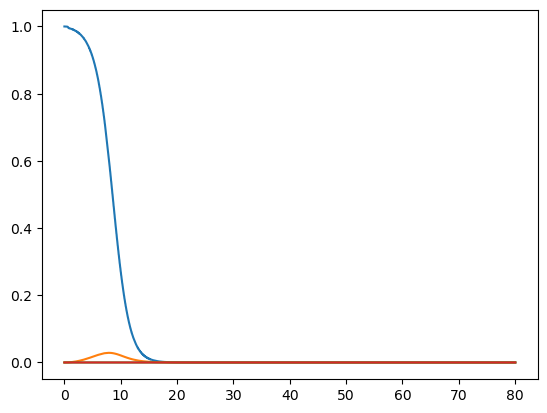

In [ ]:
rho = [qt.ket2dm(state) for state in res.states]
rho_DQD = [x.ptrace([1,2,3,4]) for x in rho]

ket_rup_rdown = basis([2,2,2,2], [0,0,1,0])
ket_rdown_rup = basis([2,2,2,2], [1,0,0,0])
ket_lup_ldown = basis([2,2,2,2], [1,1,0,1])
ket_ldown_lup = basis([2,2,2,2], [0,1,1,1])

P01 = ket_rup_rdown * ket_rup_rdown.dag()
P10 = ket_rdown_rup * ket_rdown_rup.dag()
P01_l = ket_lup_ldown * ket_lup_ldown.dag()
P10_l = ket_ldown_lup * ket_ldown_lup.dag()

p_01 = np.array([qt.expect(P01, st) for st in rho_DQD])
p_10 = np.array([qt.expect(P10, st) for st in rho_DQD])
p_01_l = np.array([qt.expect(P01_l, st) for st in rho_DQD])
p_10_l = np.array([qt.expect(P10_l, st) for st in rho_DQD])

# print(p_rup)
plt.plot(tlist, p_01, label='1up')
plt.plot(tlist, p_10, label='1down')
plt.plot(tlist, p_01_l, label='1up_l')
plt.plot(tlist, p_10_l, label='1down_l')
plt.legend
# plt.plot(tlist, p_rup1 + p_rdown1)
# plt.plot(tlist, p_rup2, label='DQD2')

In [ ]:
rho_qubit = [x.ptrace([1,3]) for x in rho]

ket00 = basis([2,2],[0,0])
ket01 = basis([2,2],[0,1])
ket10 = basis([2,2],[1,0])
ket11 = basis([2,2],[1,1])

P00 = ket00 * ket00.dag()
P01 = ket01 * ket01.dag()
P10 = ket10 * ket10.dag()
P11 = ket11 * ket11.dag()

p_00 = np.array([qt.expect(P00, st) for st in rho_qubit])
p_01 = np.array([qt.expect(P01, st) for st in rho_qubit])
p_10 = np.array([qt.expect(P10, st) for st in rho_qubit])
p_11 = np.array([qt.expect(P11, st) for st in rho_qubit])

plt.plot(tlist, p_00, label='upup')
plt.plot(tlist, p_01, label='updown')
plt.plot(tlist, p_10, label='downup')
plt.plot(tlist, p_11, label='downdown')

plt.legend()
print(f"duration: {tlist[-1]}")
print(f"tg: {tg}")


NameError: name 'rho' is not defined

80.01819997580894


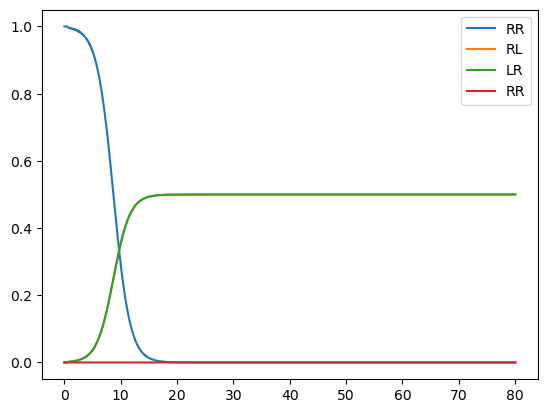

In [ ]:
rho_charge = [x.ptrace([2,4]) for x in rho]

ketRR = basis([2,2],[0,0])
ketRL = basis([2,2],[0,1])
ketLR = basis([2,2],[1,0])
ketLL = basis([2,2],[1,1])

p_RR = np.array([qt.expect(ketRR * ketRR.dag(), st) for st in rho_charge])
p_RL = np.array([qt.expect(ketRL * ketRL.dag(), st) for st in rho_charge])
p_LR = np.array([qt.expect(ketLR * ketLR.dag(), st) for st in rho_charge])
p_LL = np.array([qt.expect(ketLL * ketLL.dag(), st) for st in rho_charge])

plt.plot(tlist, p_RR, label='RR')
plt.plot(tlist, p_RL, label='RL')
plt.plot(tlist, p_LR, label='LR')
plt.plot(tlist, p_LL, label='RR')

plt.legend()

print(tlist[-1])